# **Banking Customer Churn Prediction rate**


### Import necessary libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### ETL/Data processing

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


Some strange behaviour in surname("H?"). Other data is correct though, so there is no need to clean it. But it would be necessary to check, if customerId is totally unique at this point. Maybe there are also other hidden mistakes in data(what if all cutomers with "strange" surnames have exited?).

In [3]:
strange_surnames = df["Surname"].str.contains(r'\+|\?|!|\)|\(', regex=True)
df_strange = pd.concat([df[strange_surnames], df[df["Surname"].str.len() <= 2]])
print(len(df_strange))
df_strange.head(5)

388


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0
329,330,15624528,L?,664,Germany,Male,26,7,116244.14,2,1,1,95145.14,0
437,438,15624623,Hs?,516,France,Male,35,10,104088.59,2,0,0,119666.00,0
941,942,15676521,Y?an,696,France,Female,31,8,0.00,2,0,0,191074.11,0
970,971,15805955,L?,638,France,Female,48,10,138333.03,1,1,1,47679.14,0


In [4]:
df_strange["Surname"].unique()

array(['H?', 'L?', 'Hs?', 'Y?an', 'K?', 'Y?', 'Hs?eh', 'He', 'Hu', 'Fu',
       'Ko', 'Wu', 'Li', 'Ma', 'Ho', 'Ku', 'Lo', 'Lu', 'Ni', 'Su', 'Tu',
       'Yu'], dtype=object)

Some of these are just normal surnames. So, only surnames with "?" will be left to further exploration.

In [5]:
df_strange = df_strange[df_strange["Surname"].str.contains(r'\?', regex=True)]
print(len(df_strange))
print(df_strange["Surname"].unique())
df_strange.describe()


149
['H?' 'L?' 'Hs?' 'Y?an' 'K?' 'Y?' 'Hs?eh']


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,149.000000,1.490000e+02,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5062.006711,1.570569e+07,661.845638,38.791946,5.597315,87929.695436,1.503356,0.718121,0.503356,92667.664228,0.161074
std,2838.534923,7.074683e+04,86.227757,10.029197,2.956714,59689.571142,0.540572,0.451432,0.501675,58499.850480,0.368839
min,10.000000,1.556811e+07,472.000000,22.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1528.400000,0.000000
25%,2449.000000,1.565411e+07,598.000000,31.000000,3.000000,0.000000,1.000000,0.000000,0.000000,41365.850000,0.000000
50%,5073.000000,1.571600e+07,663.000000,38.000000,6.000000,109676.520000,1.000000,1.000000,1.000000,87985.200000,0.000000
75%,7433.000000,1.576530e+07,722.000000,45.000000,8.000000,135923.160000,2.000000,1.000000,1.000000,142514.660000,0.000000
max,9911.000000,1.581387e+07,850.000000,81.000000,10.000000,174894.530000,3.000000,1.000000,1.000000,197911.520000,1.000000


In [6]:
len(df_strange[df_strange["Exited"] == 1]) / len(df_strange)

0.1610738255033557

16% ~ 20%, data of these surnames is just normal, their exited/not exited rate too. so we'll leave them alone for now. Uniqueness of
CustomerId needs to be checked too.

In [7]:
len(df["CustomerId"].unique()) == len(df["CustomerId"])

True

In [8]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
to_describe = df.copy()
d_exited = to_describe[to_describe["Exited"] == 1]
d_not_exited = to_describe[to_describe["Exited"] == 0]

In [9]:
d_exited.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.0
mean,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,1.0
std,100.321503,9.761562,2.936106,58360.794816,0.801521,0.458776,0.480358,57912.418071,0.0
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,1.0
25%,578.000000,38.000000,2.000000,38340.020000,1.000000,0.000000,0.000000,51907.720000,1.0
50%,646.000000,45.000000,5.000000,109349.290000,1.000000,1.000000,0.000000,102460.840000,1.0
75%,716.000000,51.000000,8.000000,131433.330000,2.000000,1.000000,1.000000,152422.910000,1.0
max,850.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199808.100000,1.0


In [10]:
d_not_exited.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.000000,7963.0
mean,651.853196,37.408389,5.033279,72745.296779,1.544267,0.707146,0.554565,99738.391772,0.0
std,95.653837,10.125363,2.880658,62848.040701,0.509536,0.455101,0.497045,57405.586966,0.0
min,405.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,90.070000,0.0
25%,585.000000,31.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50783.490000,0.0
50%,653.000000,36.000000,5.000000,92072.680000,2.000000,1.000000,1.000000,99645.040000,0.0
75%,718.000000,41.000000,7.000000,126410.280000,2.000000,1.000000,1.000000,148609.955000,0.0
max,850.000000,92.000000,10.000000,221532.800000,3.000000,1.000000,1.000000,199992.480000,0.0


In [11]:
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
bxplot_df = df.drop(columns=["Geography", "Gender", "Exited"])

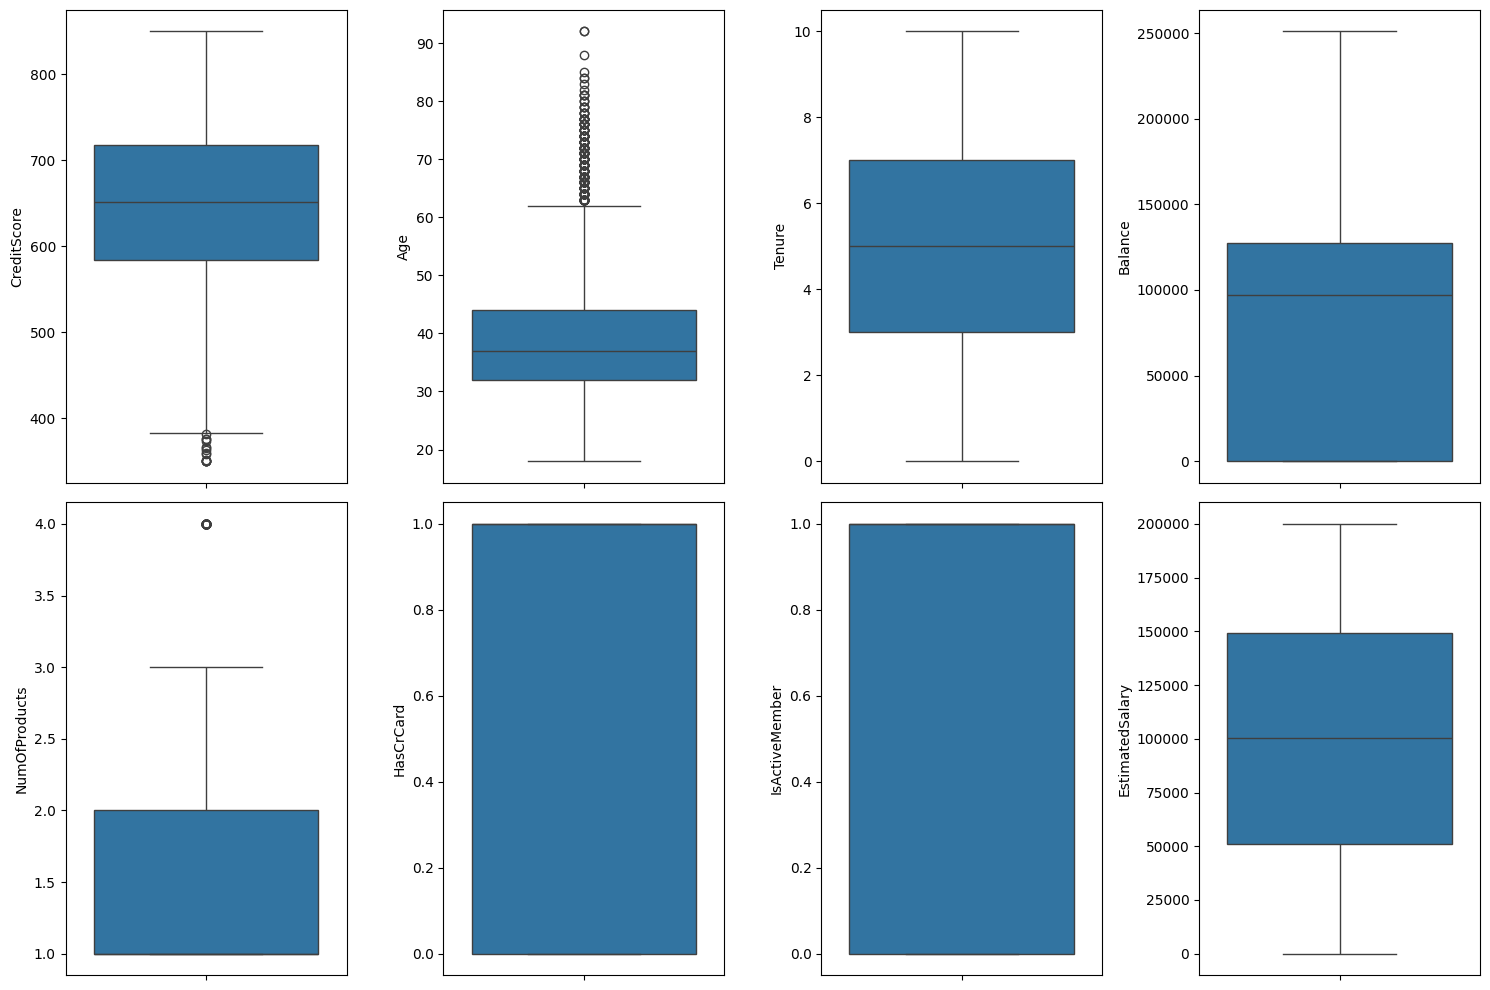

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()
for idx, col in enumerate(bxplot_df.columns):
    sns.boxplot(y = bxplot_df[col], ax = axes[idx])
    axes[idx].set_ylabel(col)
plt.tight_layout()
plt.show()

According to data characteristics, there are no missed values, nor explicit outliers. Before proceeding to machime learning, correlation between features needs to be explored. Before that, lets encode Geography and gender.

In [14]:
print(df["Geography"].unique())
print(df["Gender"].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']


In [15]:
dummies_geo = pd.get_dummies(df["Geography"], dtype=int)
dummies_gen = pd.get_dummies(df["Gender"], dtype=int)

In [16]:
df = df.drop(columns=["Geography", "Gender"])

In [17]:
df_transformed = pd.concat([df, dummies_geo, dummies_gen], axis=1)
df_transformed.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


In [18]:
corr_matrix = df_transformed.corr(method="pearson")

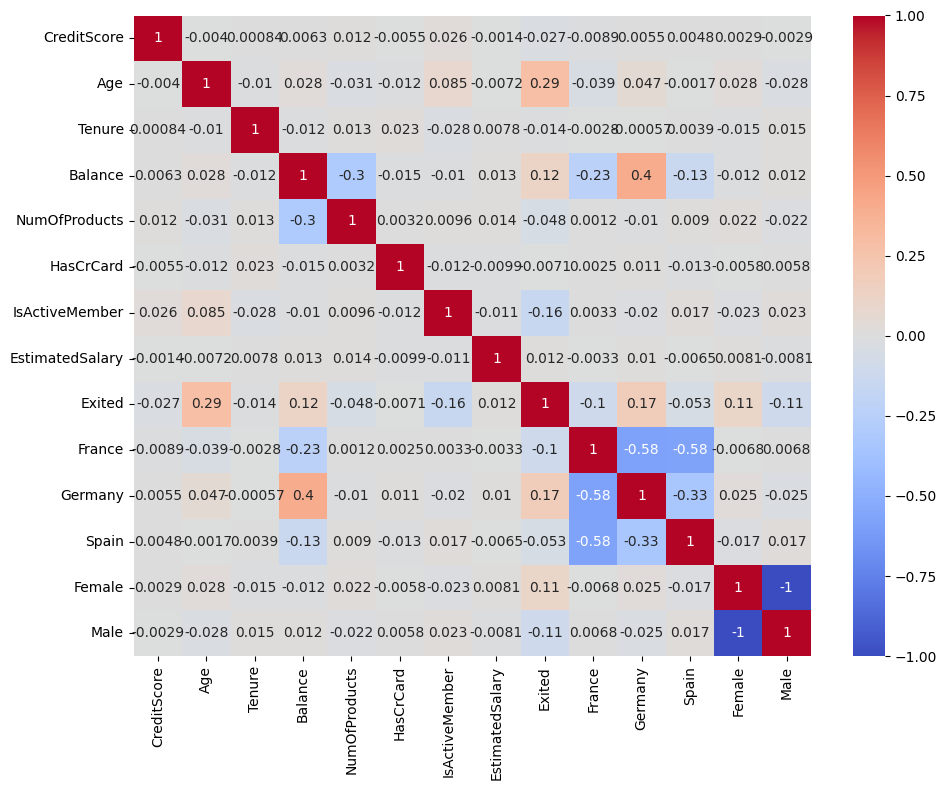

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()

Medium correlation between Balance and country: Germany is observed. Also mild correlation with "exited" and "age" could be seen. Perhaps it's possible to create new features, based on age and balance (and, maybe, country, since French and Germany correlate with balance, and with exited at the same time). But to measure improvements, obtained by feature engineering, baseline should be built.

#### Creating baseline (SMOTENC + Logistic Regression)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
scaler = StandardScaler()
to_scale = ["Age", "CreditScore", "EstimatedSalary", "Balance"]
categorical = ["HasCrCard", "IsActiveMember", "Tenure", "NumOfProducts", "France", "Germany", "Spain", "Female", "Male"]
smote = SMOTENC(categorical_features=categorical,sampling_strategy="auto", k_neighbors=5, random_state=42)
neg = 1
pos = 2.3
X, y = df_transformed.drop(columns=['Exited']), df_transformed['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
Xtrain_s =  pd.concat([X_train.drop(columns=to_scale), pd.DataFrame(scaler.fit_transform(X_train[to_scale]), columns=to_scale, index=X_train.index)], axis=1)
Xtest_s = pd.concat([X_test.drop(columns=to_scale), pd.DataFrame(scaler.transform(X_test[to_scale]), columns=to_scale, index=X_test.index)], axis=1)
X_train_s, y_train_s = smote.fit_resample(Xtrain_s, y_train)

model = LogisticRegression(class_weight={0: neg, 1: pos}, random_state=42, penalty="l2")
model.fit(X_train_s, y_train_s)
y_pred_s = model.predict_proba(Xtest_s)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_s)
roc_auc #to see, how balanced is model in total

0.7800605475587442

In [21]:
from sklearn.metrics import f1_score, recall_score


def find_best_treshold(metric):
    best = 0
    treshold = 0
    y_best = 0
    for tr in np.arange(0.1, 0.9, 0.02):
        y_pred_b = np.array([1 if i > tr else 0 for i in y_pred_s])
        if metric == "recall":
            score = recall_score(y_test, y_pred_b)
        elif metric == "f1":
            score = f1_score(y_test, y_pred_b) #banks are usually in "mature" stage of product lifecycle, so FN are more valuable to detect
        if score > best:
            best = score
            treshold = tr
            y_best = y_pred_b
    if metric == "recall":
        other_score = f1_score(y_test, y_best) #in case exited and not_exited are equivalent
    elif metric == "f1":
        other_score = recall_score(y_test, y_best)
    return [best, other_score]

    
b_f1, rec = find_best_treshold("f1")
print("maxing f1: ", b_f1,end="")
print(", recall: ", rec)
b_rec, f1 = find_best_treshold("recall")
print("maxing recall: ", b_rec, end="")
print(", f1: ", f1)

maxing f1:  0.5212835625409299, recall:  0.6513911620294599
maxing recall:  0.9967266775777414, f1:  0.33852140077821014


In [22]:
weights = model.coef_
def describe_weights(weights, X_train):
    for i in range(len(X_train.columns)):
        print(X_train.columns[i], ": ", weights[0][i])
describe_weights(weights, X_train)

CreditScore :  0.015498478884793082
Age :  -0.6267711633300064
Tenure :  0.27753224190036285
Balance :  -0.9018617957131156
NumOfProducts :  -1.5851877610633944
HasCrCard :  -0.7025780921679452
IsActiveMember :  -1.6170822334723536
EstimatedSalary :  1.17129491879047
France :  0.5731960633485326
Germany :  0.8528467409664986
Spain :  -0.10825739482461737
Female :  0.0684831736504577
Male :  0.09902763743884886


### Feature Engineering

In [23]:
df_transformed["age_balance"] = df_transformed["Balance"] / (df_transformed["Age"] + 1)
df_transformed["loyal"] = (df_transformed["NumOfProducts"] + df_transformed["HasCrCard"]) * df_transformed["Tenure"]
df_transformed["age_group"] = pd.cut(df_transformed["Age"], bins=[18, 30, 45, 60, 82], labels=["young", "middle", "mature", "elderly"])
dummies_group = pd.get_dummies(df_transformed["age_group"], dtype=int)
df_transformed = df_transformed.drop(columns=["age_group"])
df_transformed = pd.concat([df_transformed, pd.DataFrame(dummies_group, index=df_transformed.index)], axis = 1)

to_scale = ["Age", "CreditScore", "EstimatedSalary", "age_balance"]
df_transformed = df_transformed.drop(columns=["Balance", "Tenure"])
neg = 1
pos = 4
X, y = df_transformed.drop(columns=['Exited']), df_transformed['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
Xtrain_s =  pd.concat([X_train.drop(columns=to_scale), pd.DataFrame(scaler.fit_transform(X_train[to_scale]), columns=to_scale, index=X_train.index)], axis=1)
Xtest_s = pd.concat([X_test.drop(columns=to_scale), pd.DataFrame(scaler.transform(X_test[to_scale]), columns=to_scale, index=X_test.index)], axis=1)

model = LogisticRegression(class_weight={0: neg, 1: pos}, random_state=42, penalty="l2")
model.fit(Xtrain_s, y_train)

y_pred_s = model.predict_proba(Xtest_s)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_s)
print("roc_auc: ", roc_auc)
b_f1, rec = find_best_treshold("f1")
print("maxing f1: ", b_f1,end="")
print(", recall: ", rec)
b_rec, f1 = find_best_treshold("recall")
print("maxing recall: ", b_rec, end="")
print(", f1: ", f1)
weights = model.coef_
describe_weights(weights, Xtrain_s)

roc_auc:  0.8053256914705219
maxing f1:  0.5464406779661017, recall:  0.6595744680851063
maxing recall:  0.9983633387888707, f1:  0.3433717984801576
NumOfProducts :  -0.0387180296283349
HasCrCard :  -0.009648784044918963
IsActiveMember :  -0.864231073603596
France :  -0.2732731150999778
Germany :  0.5370609381262588
Spain :  -0.23546180393927138
Female :  0.27555132072865524
Male :  -0.2472253016416508
loyal :  -0.000434475525495554
young :  0.21567676695315635
middle :  0.21669392157992573
mature :  0.9717782298511078
elderly :  -1.2309775386526798
Age :  0.8151811978926488
CreditScore :  -0.09742072067242051
EstimatedSalary :  0.050040637368722996
age_balance :  0.18307074464454354


#### Final solution

In [25]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, recall_score
import numpy as np


params_lgb = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'scale_pos_weight': 4,  # ваш дисбаланс 1:4
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1
}


model_lgb = lgb.LGBMClassifier(**params_lgb)
model_lgb.fit(
    Xtrain_s, y_train,
    eval_set=[(Xtest_s, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

y_proba_lgb = model_lgb.predict_proba(Xtest_s)[:, 1]

best_f1 = 0
for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_proba_lgb >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = threshold
        best_recall = recall_score(y_test, y_pred)
print("f1: ", best_f1)
#print("roc-auc: ", roc_auc_score(y_test, y_proba_lgb))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.877633
f1:  0.6476683937823834
roc-auc:  0.877633027535506
